In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from scipy.stats import genpareto

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 20260908
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


# GAMEX Practical 3 — Generative modelling of cascading extremes with a Transformer

This practical follows one simulated multivariate process from continuous observations to generated extreme-event tokens.

We will:

1. simulate a 5-dimensional VAR(5) process with GARCH-like volatility and heavy-tailed shocks;
2. tokenise marginal exceedances on a common probability scale at $q=0.95$;
3. fit a causal Transformer to the token sequence $A_t$;
4. compare empirical and model-implied conditional probabilities, then generate future token sequences.

There is no amortisation: one data-generating process is simulated and one Transformer is fitted.

# 0. Motivation

Extreme events can occur in clusters and can propagate across components. The aim is to compress the multivariate process into a simple sequence of extreme-event tokens and ask whether an autoregressive Transformer can learn and reproduce that dependence.

<p align="center">
  <img src="figures/dip_animation.gif" alt="Dynamic interaction diagram" width="700">
</p>

## 1. Simulate a VAR(5) process with clustered volatility

Let $X_t\in\mathbb{R}^5$. We simulate
$$
X_t=\sum_{\ell=1}^{5}A_\ell X_{t-\ell}+\varepsilon_t,\qquad\varepsilon_t=\operatorname{diag}(\sigma_{1,t},\ldots,\sigma_{5,t})\eta_t,
$$
where the standardised shock $\eta_t\sim t_\nu(0,R)$ is multivariate Student-$t$.

The two parts of the innovation have different roles:
- $\eta_t$ produces **heavy-tailed shocks** and contemporaneous dependence through $\Lambda$;
- $\sigma_{i,t}$ gives the **time-varying volatility** of component $i$.

The conditional variance follows
$$
\sigma_{i,t}^{2}
=
\omega_i
+\beta_i\sigma_{i,t-1}^{2}
+\alpha_i\varepsilon_{i,t-1}^{2}
+\gamma_i\frac{1}{5}\sum_{j=1}^{5}\varepsilon_{j,t-1}^{2}.
$$

The VAR coefficients, cross-component links, correlations, and volatility parameters are generated once from the fixed random seed. This gives temporal dependence, cross-component interaction, volatility clustering, and heavy tails without imposing a fixed direction of propagation.

In [2]:
def simulate_var5_garch(T=50_000, burn=5_000, seed=SEED):
    rng = np.random.default_rng(seed)
    d = 5
    p = 5
    df = 3.0

    # ============================================================
    # 1. Random VAR interaction structure
    # ============================================================
    # B[i, j] describes how component j influences component i.
    # Off-diagonal interactions are generated randomly:
    #   - some are zero,
    #   - some are positive,
    #   - some are negative.
    # ============================================================
    B = np.zeros((d, d))
    # Random own-component persistence
    np.fill_diagonal(B, rng.uniform(0.28, 0.38, size=d))
    # Random cross-component interactions
    cross_effects = rng.normal(loc=0.0, scale=0.06, size=(d, d))
    # Randomly remove some cross-connections
    connection_mask = (rng.uniform(size=(d, d)) < 0.50)
    np.fill_diagonal(connection_mask, False)
    B[connection_mask] = cross_effects[connection_mask]

    # ============================================================
    # 2. VAR(5) lag structure
    # ============================================================
    # The directions are random, with lag-specific interaction strengths.
    # ============================================================
    lag_weights = np.array([0.48, 0.24, 0.74, 0.25, 0.85])
    A = lag_weights[:, None, None] * B[None, :, :]

    # ============================================================
    # 3. Check VAR stability
    # ============================================================
    def spectral_radius(A):
        p, d, _ = A.shape
        companion = np.zeros((p * d, p * d))
        companion[:d, :p * d] = np.hstack(A)

        if p > 1:
            companion[d:, :-d, ] = np.eye(d * (p - 1))

        return np.max(np.abs(np.linalg.eigvals(companion)))

    # Scale down the coefficients if a random draw happens to produce an unstable VAR.
    while spectral_radius(A) >= 0.95:
        A *= 0.90
    var_radius = spectral_radius(A)

    # ============================================================
    # 4. Random contemporaneous dependence
    # ============================================================
    # Instead of giving every pair correlation 0.25, generate a random positive-definite correlation matrix.
    # This makes some components more strongly dependent than others, without imposing a direction.
    # ============================================================
    factor_loadings = rng.normal(loc=0.0, scale=0.80, size=(d, 2))
    covariance = factor_loadings @ factor_loadings.T + 0.70 * np.eye(d)
    standard_deviation = np.sqrt(np.diag(covariance))
    R = covariance / np.outer(standard_deviation, standard_deviation)
    chol_R = np.linalg.cholesky(R)
    
    # ============================================================
    # 5. Random GARCH-like volatility dynamics
    # ============================================================
    # Each component has slightly different volatility behaviour, but these parameters are 
    # generated randomly rather than assigning a special role to a particular component.
    # ============================================================
    alpha = rng.uniform(0.05, 0.08, size=d)
    gamma = rng.uniform(0.01, 0.03, size=d)
    # Total persistence of conditional variance
    volatility_persistence = rng.uniform(0.93, 0.97, size=d)
    beta = volatility_persistence - alpha - gamma
    # Approximately keeps unconditional variance near one
    omega = 1.0 - volatility_persistence

    # ============================================================
    # 6. Simulate
    # ============================================================
    n = T + burn
    x = np.zeros((n, d))
    sigma2 = np.ones((n, d))
    shock = np.zeros((n, d))

    for t in range(p, n):
        # Conditional variance
        previous_shock_sq = shock[t - 1] ** 2
        sigma2[t] = omega + beta * sigma2[t - 1] + alpha * previous_shock_sq + gamma * previous_shock_sq.mean()

        # Correlated heavy-tailed Student-t shock eta_t
        gaussian = chol_R @ rng.normal(size=d)
        eta = gaussian / np.sqrt(rng.chisquare(df) / df)

        # Standardise each marginal to variance approximately one
        eta *= np.sqrt((df - 2.0) / df)
        conditional_mean = np.zeros(d)
        for lag in range(1, p + 1):
            conditional_mean += A[lag - 1]@ x[t - lag]

        # epsilon_t = diag(sigma_1,t, ..., sigma_5,t) eta_t
        shock[t] = np.sqrt(sigma2[t]) * eta

        # Observation
        x[t] = conditional_mean + shock[t]


    # ============================================================
    # Some useful information about the realised DGP
    # ============================================================
    # print("VAR spectral radius:", np.round(var_radius, 3))
    print("\nRandom base VAR matrix B:")
    print(np.round(B, 3))
    print(r"Innovation correlation matrix $R$:")
    print(np.round(R, 3))
    print("\nGARCH-like parameters:")
    print("alpha =", np.round(alpha, 3))
    print("beta  =", np.round(beta, 3))
    print("gamma =", np.round(gamma, 3))
    dgp = {
        "R": R,
        "chol_R": chol_R,
        "df": df,
        "omega": omega,
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
    }

    return (x[burn:], sigma2[burn:], shock[burn:], A, dgp)


# ============================================================
# Generate the process
# ============================================================
X, SIGMA2, SHOCK, A, DGP = simulate_var5_garch()

print("\nX shape:")
print(X.shape)

print("\nMarginal standard deviations:")
print(np.round(X.std(axis=0), 3))

print("\n98% marginal quantiles:")
print(np.round(np.quantile(X, 0.98, axis=0), 3))


Random base VAR matrix B:
[[ 0.367  0.    -0.015 -0.034  0.   ]
 [ 0.     0.345  0.     0.     0.   ]
 [ 0.    -0.019  0.356  0.047  0.01 ]
 [ 0.     0.     0.127  0.32  -0.047]
 [ 0.    -0.031  0.     0.     0.321]]
Innovation correlation matrix $R$:
[[ 1.     0.024  0.224 -0.184 -0.17 ]
 [ 0.024  1.     0.174 -0.622  0.311]
 [ 0.224  0.174  1.    -0.437 -0.212]
 [-0.184 -0.622 -0.437  1.    -0.088]
 [-0.17   0.311 -0.212 -0.088  1.   ]]

GARCH-like parameters:
alpha = [0.079 0.051 0.068 0.058 0.073]
beta  = [0.872 0.901 0.842 0.874 0.859]
gamma = [0.013 0.012 0.022 0.03  0.023]

X shape:
(50000, 5)

Marginal standard deviations:
[1.354 1.179 1.056 1.288 1.097]

98% marginal quantiles:
[2.059 2.145 2.137 2.056 2.004]


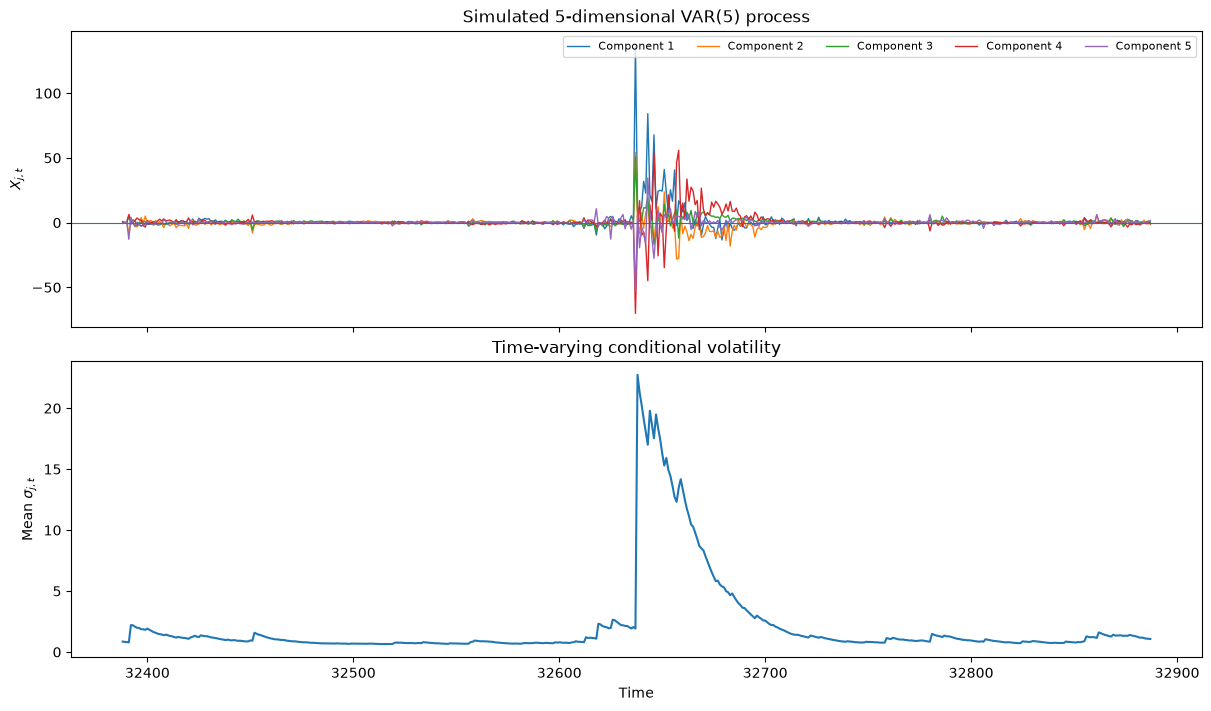

In [3]:
WINDOW = 500

# Find the time with the largest average conditional variance
centre = np.argmax(SIGMA2.mean(axis=1))
start = max(0, min(len(X) - WINDOW, centre - WINDOW // 2))
stop = start + WINDOW
time = np.arange(start, stop)
SIGMA = np.sqrt(SIGMA2)

# ------------------------------------------------------------
# Plot the process and its time-varying volatility
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
# Simulated multivariate process
for j in range(X.shape[1]):
    axes[0].plot(time, X[start:stop, j], linewidth=1, label=f"Component {j + 1}")

axes[0].axhline(0, linewidth=0.8)
axes[0].set_ylabel(r"$X_{j,t}$")
axes[0].set_title("Simulated 5-dimensional VAR(5) process")
axes[0].legend(ncol=5, fontsize=8)

# Mean conditional volatility
axes[1].plot(time, SIGMA[start:stop].mean(axis=1), linewidth=1.5)
axes[1].set_xlabel("Time")
axes[1].set_ylabel(r"Mean $\sigma_{j,t}$")
axes[1].set_title("Time-varying conditional volatility")
plt.show()

The upper panel shows a short section of the simulated process around a high-volatility period. The lower panel shows the corresponding mean conditional volatility, making volatility clustering visible before tokenisation.

## 2. Tokenise extremes on a common probability scale

Thresholds are estimated **from the training period only**. For component $j$,

$$
u_j=\widehat F_{j,\mathrm{train}}^{-1}(q),\qquad q=0.95.
$$

Only observations above $u_j$ are modelled by the GPD. For the excess $Y_{t,j}=X_{t,j}-u_j>0,$ we fit
$$
Y_{t,j}\mid X_{t,j}>u_j \sim \operatorname{GPD}(\xi_j,\sigma_j),
$$
where $\xi_j$ and $\sigma_j>0$ are the shape and scale parameters. An exceedance $x>u_j$ is mapped to
$$
\widehat F_j(x)=q+(1-q)\,G_{\widehat\xi_j,\widehat\sigma_j}(x-u_j),
$$
so all exceedances are compared on the same interval $(q,1)$.

We then define
$$
A_t=
\begin{cases}
0, & X_{t,j}\le u_j\ \text{for all }j,\\[2mm]
\displaystyle
\arg\max_{j:\,X_{t,j}>u_j}
\widehat F_j(X_{t,j}), & \text{otherwise}.
\end{cases}
$$

Thus $A_t=0$ is a **quiet** time point, while $A_t\in\{1,\ldots,5\}$ identifies the component with the most extreme probability-scale exceedance.

In [4]:
Q = 0.95
n = len(X)
n_train = int(0.70 * n)
n_val = int(0.25 * n)

X_train = X[:n_train]
X_val = X[n_train:n_train + n_val]
X_test = X[n_train + n_val:]

print(X_train.shape, X_val.shape, X_test.shape)

thresholds = np.quantile(X_train, Q, axis=0)

def fit_gpd_tail(x, thresholds):
    n_components = x.shape[1]
    shape = np.empty(n_components)
    scale = np.empty(n_components)

    for j in range(n_components):
        excesses = x[:, j][x[:, j] > thresholds[j]] - thresholds[j]
        xi, _, beta = genpareto.fit(excesses, floc=0)
        shape[j] = xi
        scale[j] = beta
    return shape, scale

gpd_shape, gpd_scale = fit_gpd_tail(X_train, thresholds)
print("component         threshold       shape           scale")
print("-------------------------------------------------------")

for j in range(X.shape[1]):
    print(f"{j + 1:^9d}", f"{thresholds[j]:>15.3f}", f"{gpd_shape[j]:>13.3f}", f"{gpd_scale[j]:>15.3f}")

(35000, 5) (12500, 5) (2500, 5)
component         threshold       shape           scale
-------------------------------------------------------
    1               1.389         0.518           0.609
    2               1.460         0.429           0.646
    3               1.429         0.319           0.661
    4               1.377         0.496           0.594
    5               1.347         0.415           0.625


The next fit uses only threshold excesses from the training sample. The fitted GPD shape $\widehat\xi_j$ should not be compared directly with the Student-$t$ degrees of freedom $\nu$: for a standard Student-$t_\nu$ tail the asymptotic reference is $\xi\approx 1/\nu$, while $X_t$ also contains VAR dependence and stochastic volatility.

Training token frequencies
token 0:  0.8085   (quiet)
token 1:  0.0373   (component 1)
token 2:  0.0367   (component 2)
token 3:  0.0375   (component 3)
token 4:  0.0421   (component 4)
token 5:  0.0379   (component 5)

Probability of any extreme token: 0.1915


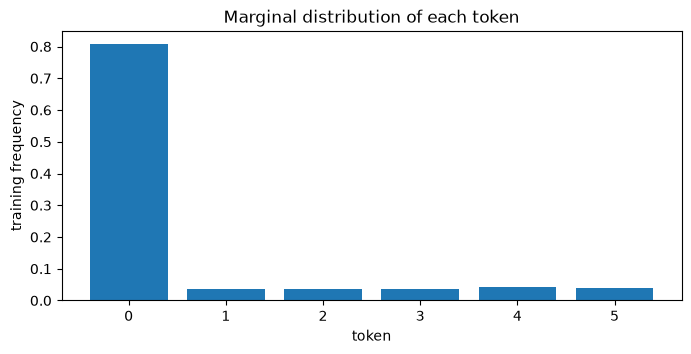

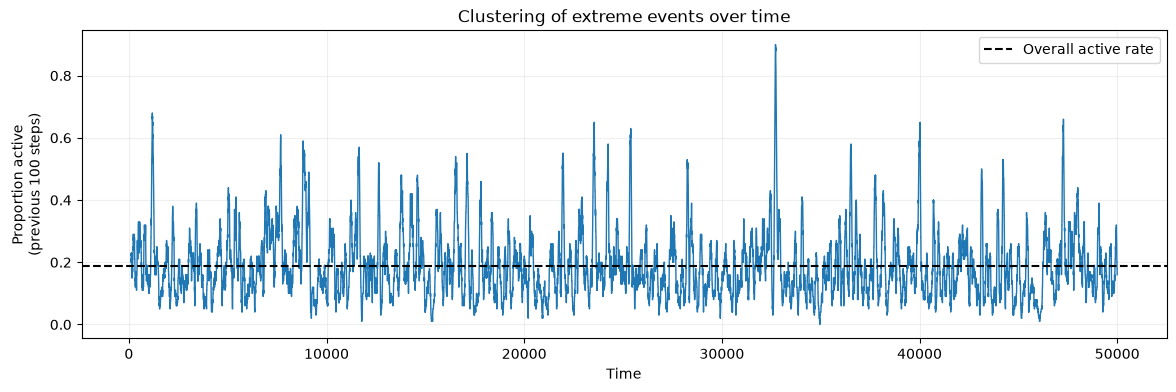

In [5]:
def probability_scale_tokens(x, thresholds, gpd_shape, gpd_scale, q=0.95):
    n, d = x.shape
    active = x > thresholds

    scores = np.full((n, d), -np.inf)
    for j in range(d):
        mask = active[:, j]
        excesses = x[mask, j] - thresholds[j]
        tail_cdf = genpareto.cdf(excesses, c=gpd_shape[j], loc=0, scale=gpd_scale[j])
        scores[mask, j] = q + (1.0 - q) * tail_cdf

    tokens = np.zeros(n, dtype=np.int64)
    any_extreme = active.any(axis=1)
    tokens[any_extreme] = scores[any_extreme].argmax(axis=1) + 1
    return tokens


tokens = probability_scale_tokens(X, thresholds=thresholds, gpd_shape=gpd_shape, gpd_scale=gpd_scale, q=Q)
tokens_train = tokens[:n_train]
tokens_val = tokens[n_train:n_train + n_val]
tokens_test = tokens[n_train + n_val:]

freq = np.bincount(tokens_train, minlength=6) / len(tokens_train)

print("Training token frequencies")
for token, p in enumerate(freq):
    label = "quiet" if token == 0 else f"component {token}"
    print(f"token {token}: {p:7.4f}   ({label})")

print(f"\nProbability of any extreme token: {1 - freq[0]:.4f}")

plt.figure(figsize=(8, 3.5))
plt.bar(np.arange(6), freq)
plt.xticks(np.arange(6))
plt.xlabel("token")
plt.ylabel("training frequency")
plt.title("Marginal distribution of each token")
plt.show()

WINDOW = 100
exceedance_count = (X > thresholds[None, :]).sum(axis=1)
active = (exceedance_count > 0).astype(float)
rolling_active_rate = np.convolve(active,np.ones(WINDOW) / WINDOW,mode="valid")
time = np.arange(WINDOW - 1, len(active))
plt.figure(figsize=(14, 4))
plt.plot(time, rolling_active_rate, linewidth=1)
plt.axhline(active.mean(), linestyle="--", label="Overall active rate", color = "black")
plt.xlabel("Time")
plt.ylabel(f"Proportion active\n(previous {WINDOW} steps)")
plt.title("Clustering of extreme events over time")
plt.legend()
plt.grid(alpha=0.2,)
plt.show()

The token-frequency plot shows the class imbalance created by thresholding. The rolling curve summarises clustering through
$$
\widehat p_t=\frac{1}{W}\sum_{s=t-W+1}^{t}\mathbb{I}\{A_s\neq0\},
$$
with $W=100$. Peaks indicate periods where active extreme tokens occur much more frequently than their overall average rate.

## 3. Fit a causal Transformer

The Transformer sees only the categorical sequence $A_t$. It does not observe $X_t$, $\sigma_t^2$, the VAR matrices, or the simulation parameters.

With a context of length $L$, the model learns next-token probabilities of the form
$$
p_\theta\!\left(A_{t+1}\mid A_{t-L+1:t}\right).
$$

Training uses autoregressive cross-entropy, equivalent to minimising the negative log-likelihood of the observed next tokens. The implementation below uses token and position embeddings, causal self-attention, four Transformer layers, and a six-category output distribution.

<p align="center">
  <img src="figures/cascading_extremes_transformer_schematic.png" alt="transformer schematic" width="900">
</p>

In [6]:

class ExtremeTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=6,
        context_len=10,
        d_model=64,
        nhead=4,
        d_ff = 128,
        num_layers=4,
        dropout=0.10,
    ):
        super().__init__()
        self.context_len = context_len
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(context_len, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids):
        batch_size, sequence_length = token_ids.shape
        positions = torch.arange(sequence_length, device=token_ids.device)
        h = self.token_embedding(token_ids) + self.position_embedding(positions)[None, :, :]
        # True above the diagonal means "do not attend to the future".
        causal_mask = torch.triu(torch.ones(sequence_length, sequence_length, dtype=torch.bool, device=token_ids.device), diagonal=1)
        h = self.transformer(h, mask=causal_mask)
        h = self.norm(h)

        return self.output(h)

### Training and model selection

Training uses randomly sampled token windows. A cosine scheduler gradually reduces the learning rate, and the model weights are saved whenever the validation NLL reaches a new minimum. The saved checkpoint, rather than the final epoch, is used for subsequent evaluation.

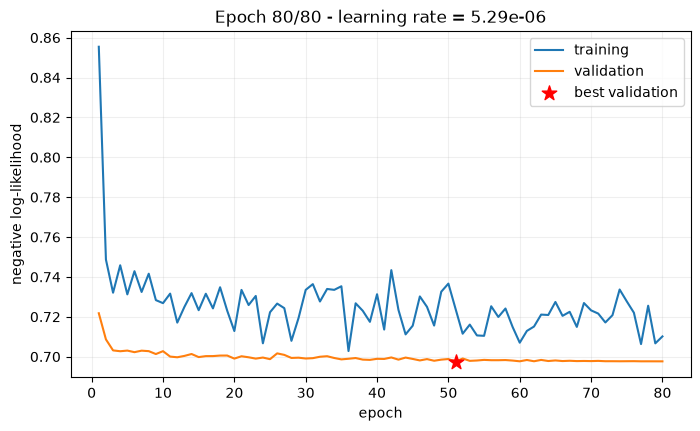

epoch  80/80 | train NLL = 0.7101 | val NLL = 0.6976 | lr = 5.29e-06
best epoch = 51 | best val NLL = 0.6974


In [7]:
CONTEXT_LEN = 10
VOCAB_SIZE = 6
BATCH_SIZE = 128

train_tensor = torch.tensor(tokens_train, dtype=torch.long)
val_tensor = torch.tensor(tokens_val, dtype=torch.long)
test_tensor = torch.tensor(tokens_test, dtype=torch.long)

def random_batch(sequence, batch_size, context_len):
    starts = torch.randint(0, len(sequence) - context_len - 1, (batch_size,))
    offsets = torch.arange(context_len)
    index = starts[:, None] + offsets[None, :]

    x = sequence[index]
    y = sequence[index + 1]

    return x.to(device), y.to(device)

@torch.inference_mode()
def evaluate_nll(
    model,
    sequence,
    batch_size,
    context_len,
):

    model.eval()

    # Every possible window of length CONTEXT_LEN + 1
    #
    # Example:
    # [z1, ..., z10, z11]
    # [z2, ..., z11, z12]
    # ...
    windows = sequence.unfold(
        dimension=0,
        size=context_len + 1,
        step=1,
    )

    total_nll = 0.0
    total_tokens = 0

    for start in range(
        0,
        len(windows),
        batch_size,
    ):

        batch = windows[
            start:start + batch_size
        ]

        # Input:
        # z_t, ..., z_{t+L-1}
        x_batch = (
            batch[:, :-1]
            .contiguous()
            .to(device)
        )

        # Targets:
        # z_{t+1}, ..., z_{t+L}
        y_batch = (
            batch[:, 1:]
            .contiguous()
            .to(device)
        )

        logits = model(x_batch)

        loss = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),
            y_batch.reshape(-1),
            reduction="sum",
        )

        total_nll += loss.item()
        total_tokens += y_batch.numel()

    return total_nll / total_tokens

# Code for random batch evaluation
# def evaluate_nll(
#     model,
#     sequence,
#     batch_size,
#     context_len,
#     n_batches=35,
# ):

#     model.eval()

#     losses = []

#     for _ in range(n_batches):
#         x_batch, y_batch = random_batch(sequence, batch_size, context_len)
#         logits = model(x_batch)
#         loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), y_batch.reshape(-1))
#         losses.append(loss.item())

#     return np.mean(losses)

model = ExtremeTransformer(vocab_size=VOCAB_SIZE, context_len=CONTEXT_LEN).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=7.5e-4, weight_decay=1e-4)
N_EPOCHS = 80
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=5e-6)
STEPS_PER_EPOCH = (
    25 if device.type == "cuda"
    else 10
)
history = {"train_nll": [], "val_nll": [], "lr": []}

BEST_CHECKPOINT = "best_val_model.pt"
best_val_nll = np.inf
best_epoch = 0

for epoch in range(1, N_EPOCHS + 1):

    model.train()
    epoch_losses = []

    for _ in range(STEPS_PER_EPOCH):
        x_batch, y_batch = random_batch(train_tensor, BATCH_SIZE, CONTEXT_LEN)
        logits = model(x_batch)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), y_batch.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_losses.append(loss.item())
   
    train_nll = np.mean(epoch_losses)
    val_nll = evaluate_nll(model, val_tensor, BATCH_SIZE, CONTEXT_LEN)


    # --------------------------------------------------
    # Save best checkpoint
    # --------------------------------------------------

    if val_nll < best_val_nll:
        best_val_nll = val_nll
        best_epoch = epoch

        torch.save(
            model.state_dict(),
            BEST_CHECKPOINT
        )
        # torch.save(
        #     {
        #         "epoch": epoch,
        #         "model_state_dict": model.state_dict(),
        #         "optimizer_state_dict": optimizer.state_dict(),
        #         "scheduler_state_dict": scheduler.state_dict(),
        #         "val_nll": val_nll,
        #     }, BEST_CHECKPOINT)


    # Current learning rate
    current_lr = optimizer.param_groups[0]["lr"]
    history["train_nll"].append(train_nll)
    history["val_nll"].append(val_nll)
    history["lr"].append(current_lr)
    scheduler.step()

    clear_output(wait=True)

    epochs = np.arange(1, len(history["train_nll"]) + 1)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(epochs, history["train_nll"], label="training")
    ax.plot(epochs, history["val_nll"], label="validation")
    ax.scatter(best_epoch, best_val_nll, marker="*", s=120, label="best validation", zorder=5, color="red")
    ax.set_xlabel("epoch")
    ax.set_ylabel("negative log-likelihood")
    ax.set_title(f"Epoch {epoch}/{N_EPOCHS} - learning rate = {current_lr:.2e}")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.show()


    print(
        f"epoch {epoch:3d}/{N_EPOCHS} | "
        f"train NLL = {train_nll:.4f} | "
        f"val NLL = {val_nll:.4f} | "
        f"lr = {current_lr:.2e}"
    )

    print(
        f"best epoch = {best_epoch} | "
        f"best val NLL = {best_val_nll:.4f}"
    )

In [8]:
best_weights = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(
    best_weights
)

model.eval()

print(
    f"Loaded best model from epoch "
    f"{best_epoch} "
    f"with validation NLL = "
    f"{best_val_nll:.4f}"
)

Loaded best model from epoch 51 with validation NLL = 0.6974


The best validation checkpoint is now restored. From this point onward, `model` refers to the selected model used for test evaluation and generation.

## 4. Diagnose conditional probabilities and generate cascades

We evaluate more than the training loss. The diagnostics ask whether the fitted model reproduces the **probability structure of future extreme tokens**.

We use:

- test negative log-likelihood, compared with an IID token baseline;
- empirical one-step transition probabilities versus Transformer-implied transitions;
- Monte Carlo rollouts from the known DGP and the Transformer;
- marginal token probabilities from generated continuations.

The best validation checkpoint is loaded before these diagnostics.

In [9]:
@torch.inference_mode()
def one_step_test_predictions(
    model,
    sequence,
    context_len,
    batch_size=512,
):
    model.eval()
    sequence = torch.as_tensor(sequence, dtype=torch.long)
    # Context ending at t predicts token t+1
    current_indices = np.arange(context_len - 1, len(sequence) - 1)
    contexts = torch.stack([sequence[t - context_len + 1:t + 1] for t in current_indices])
    probabilities = []

    for start_batch in range(0, len(contexts), batch_size):
        x_batch = contexts[start_batch:start_batch + batch_size].to(device)
        next_logits = model(x_batch)[:, -1, :]
        probabilities.append(next_logits.softmax(dim=-1).cpu())

    probabilities = torch.cat(probabilities).numpy()
    current = np.asarray(sequence[current_indices])
    target = np.asarray(sequence[current_indices + 1])

    return (current, target, probabilities)

current_test, target_test, test_probs = one_step_test_predictions(model, tokens_test, CONTEXT_LEN)
transformer_test_nll = -np.log(test_probs[np.arange(len(target_test)), target_test]+ 1e-12).mean()
iid_prob = np.bincount(tokens_train, minlength=VOCAB_SIZE)
iid_prob = iid_prob / iid_prob.sum()
iid_test_nll = -np.log(iid_prob[target_test] + 1e-12).mean()

print(f"Transformer test NLL: {transformer_test_nll:.4f}")
print(f"IID-token baseline NLL: {iid_test_nll:.4f}")

Transformer test NLL: 0.7350
IID-token baseline NLL: 0.8190


### Empirical transition probabilities

The transition probabilities of the token process are not available in a simple closed form, so we estimate them from the held-out test sequence. For $i,j\in\{0,\ldots,5\}$,

$$
\widehat P_{\mathrm{emp}}(j\mid i)=\frac{\sum_t \mathbb{I}\{A_t=i,\;A_{t+1}=j\}}{\sum_t \mathbf 1\{A_t=i\}}.
$$

The Transformer conditions on the full recent history. To obtain a comparable $i\to j$ transition probability, we average its next-token probabilities over all test contexts ending in $A_t=i$:

$$
\widehat P_\theta(j\mid i)=\frac{1}{N_i}
\sum_{t:A_t=i}
p_\theta\!\left(
A_{t+1}=j\mid A_{t-L+1:t}
\right).
$$

The heatmaps compare these two estimates and their absolute difference.

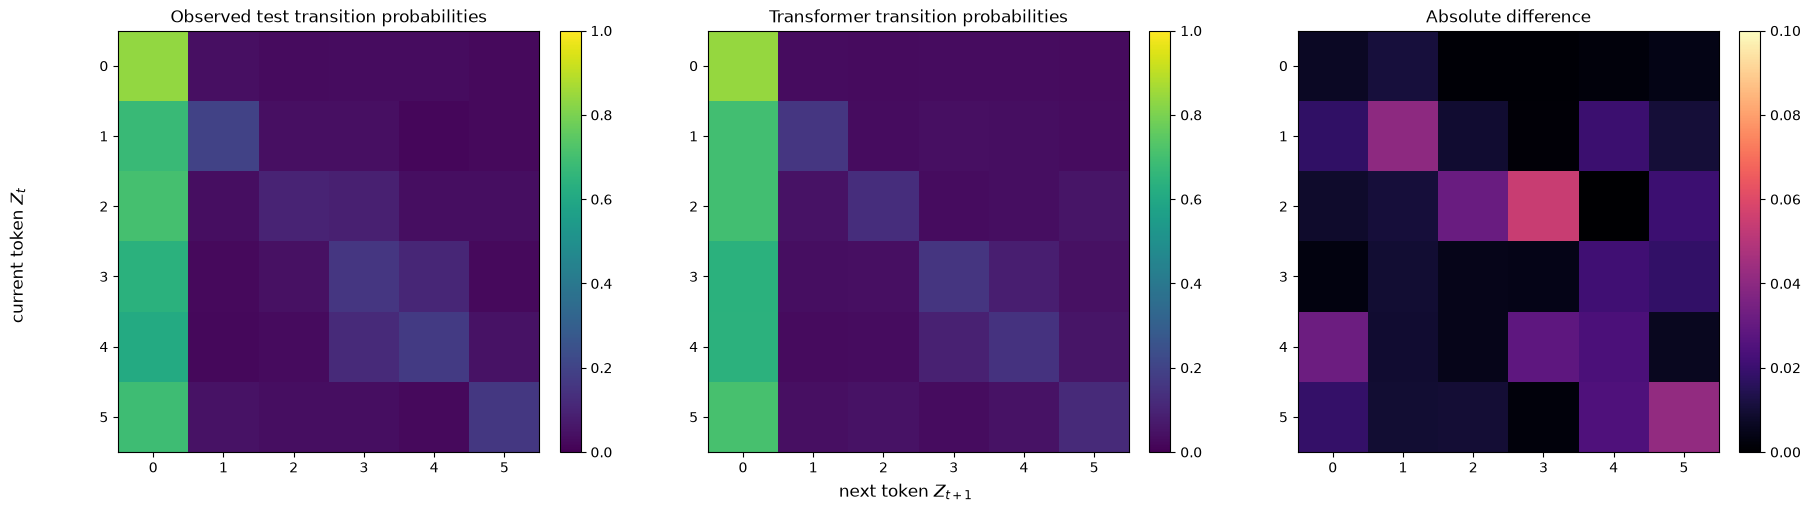

In [10]:
def observed_transition_matrix(current, target, vocab_size=6):
    counts = np.zeros((vocab_size, vocab_size))

    for i, j in zip(current, target):
        counts[i, j] += 1

    row_total = counts.sum(axis=1, keepdims=True)

    return np.divide(
        counts,
        row_total,
        out=np.zeros_like(counts),
        where=row_total > 0,
    )


def transformer_transition_matrix(
    current,
    probabilities,
    vocab_size=6,
):
    matrix = np.zeros((vocab_size, vocab_size))
    for i in range(vocab_size):
        mask = current == i

        if mask.any():
            matrix[i] = probabilities[mask].mean(axis=0)

    return matrix

def print_transition_matrix(
    matrix,
    title,
    decimals=4,
):

    print("\n" + title)
    print("-" * 72)

    # Column headings
    header = (
        "current \\ next"
        + "".join(
            f"{j:>10d}"
            for j in range(matrix.shape[1])
        )
    )

    print(header)

    # Rows
    for i in range(matrix.shape[0]):

        row = (
            f"{i:>14d}"
            + "".join(
                f"{matrix[i, j]:>10.{decimals}f}"
                for j in range(matrix.shape[1])
            )
        )

        print(row)


observed_transition = observed_transition_matrix(current_test, target_test)
model_transition = transformer_transition_matrix(current_test, test_probs)
transition_difference = np.abs(observed_transition - model_transition)

# print_transition_matrix(observed_transition, "Observed test transition probabilities")
# print_transition_matrix(model_transition, "Transformer transition probabilities")
# print_transition_matrix(transition_difference, "Absolute difference")

def plot_transition_matrices_side_by_side(
    observed_transition,
    model_transition,
    transition_difference,
):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    matrices = [observed_transition, model_transition, transition_difference]
    titles = ["Observed test transition probabilities", "Transformer transition probabilities", "Absolute difference"]

    for i, (ax, matrix, title) in enumerate(zip(axes, matrices, titles)):
        if i < 2:
            image = ax.imshow(matrix, vmin=0, vmax=1, interpolation="nearest", cmap="viridis")
        else:
            image = ax.imshow(matrix, vmin=0, vmax=0.1, interpolation="nearest", cmap="magma")

        ax.set_xticks(np.arange(6))
        ax.set_yticks(np.arange(6))
        ax.set_title(title)
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.supxlabel(r"next token $Z_{t+1}$")
    fig.supylabel(r"current token $Z_t$")
    plt.show()

plot_transition_matrices_side_by_side(
    observed_transition,
    model_transition,
    transition_difference,
)


### Autoregressive generation

Generation starts from an observed token prefix. At each step the Transformer samples one token from its predicted categorical distribution, appends it to the sequence, and uses the updated history to generate the next token.

In [11]:
@torch.inference_mode()
def generate_continuations(
    model,
    prefix,
    n_future,
    n_generated,
    context_len,
):
    model.eval()
    prefix = torch.as_tensor(prefix, dtype=torch.long, device=device)
    sequences = prefix[None, :].repeat(n_generated, 1)
    generated = []
    for _ in range(n_future):
        context = sequences[:, -context_len:]
        logits = model(context)[:, -1, :]

        probabilities = torch.softmax(logits, dim=-1)
        next_token = torch.multinomial(probabilities, num_samples=1)
        generated.append(next_token.squeeze(1))
        sequences = torch.cat([sequences, next_token,], dim=1)

    generated = torch.stack(generated, dim=1)
    return generated.cpu().numpy()


def marginal_probability_comparison(
    model,
    tokens,
    prefix_length,
    n_future,
    n_generated,
    context_len,
    vocab_size,
):

    # Use the selected prefix as the conditioning sequence
    prefix = tokens[:prefix_length]
    # Actual continuation
    observed_future = tokens[prefix_length:(prefix_length + n_future)]
    # Generate possible continuations
    generated_future = generate_continuations(
        model=model,
        prefix=prefix,
        n_future=n_future,
        n_generated=n_generated,
        context_len=context_len,
    )

    observed_prob = np.bincount(observed_future, minlength=vocab_size,).astype(float)
    observed_prob /= observed_prob.sum()
    generated_prob = np.array([(generated_future == token).mean() for token in range(vocab_size)])

    return (observed_prob, generated_prob, prefix, generated_future)

### Monte Carlo rollout comparison

To study more than one-step transitions, many future paths are simulated from the same test location. The DGP rollout starts from the known continuous VAR-GARCH state, whereas the Transformer starts only from the observed token prefix. The comparison therefore reflects both model error and information lost during tokenisation.

In [12]:
N_ROLLOUTS = 1000
N_FUTURE = 60
VOCAB_SIZE = 6
P = 5

best_weights = torch.load(BEST_CHECKPOINT, map_location=device, weights_only=True)
model.load_state_dict(best_weights)
model.eval()

candidate_anchors = np.arange(CONTEXT_LEN - 1, len(tokens_test) - N_FUTURE)
recent_activity = np.array([np.sum(tokens_test[t - CONTEXT_LEN + 1:t + 1] != 0) for t in candidate_anchors])
test_anchor = candidate_anchors[np.argmax(recent_activity)]
prefix = tokens_test[test_anchor - CONTEXT_LEN + 1:test_anchor + 1]
test_start = n_train + n_val
continuous_anchor = test_start + test_anchor

print("Test anchor:",test_anchor)
print("Number of extreme tokens in prefix:",np.sum(prefix != 0))
print("Observed prefix:",prefix)

def tokenise_one_step(x, thresholds, gpd_shape, gpd_scale, q=Q,):
    n, d = x.shape
    active = x > thresholds[None, :]

    scores = np.full((n, d), -np.inf)
    for j in range(d):
        mask = active[:, j]
        if not mask.any():
            continue

        excess = x[mask, j] - thresholds[j]
        tail_cdf = genpareto.cdf(excess, c=gpd_shape[j], loc=0, scale=gpd_scale[j])
        scores[mask, j] = q + (1.0 - q) * tail_cdf

    tokens = np.zeros(n, dtype=np.int64)
    any_active = active.any(axis=1)
    tokens[any_active] = scores[any_active].argmax(axis=1)+ 1

    return tokens

Test anchor: 31
Number of extreme tokens in prefix: 10
Observed prefix: [3 2 4 2 2 2 3 4 5 2]


Mean absolute probability error:  0.0556


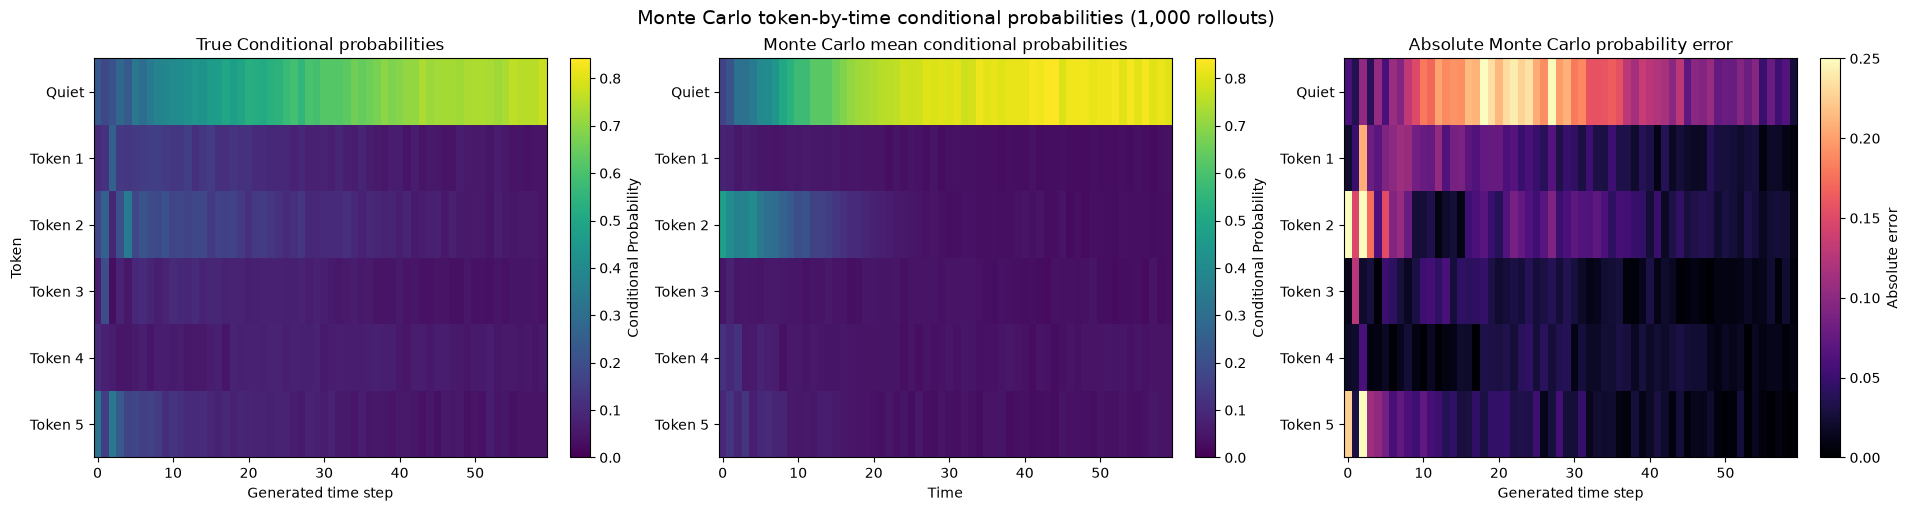

In [13]:
def generate_dgp_rollouts(
    X,
    SIGMA2,
    SHOCK,
    anchor,
    A,
    DGP,
    thresholds,
    gpd_shape,
    gpd_scale,
    n_future=128,
    n_rollouts=1000,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    p = A.shape[0]
    chol_R = DGP["chol_R"]
    df = DGP["df"]
    omega = DGP["omega"]
    alpha = DGP["alpha"]
    beta = DGP["beta"]
    gamma = DGP["gamma"]

    initial_history = X[anchor - p + 1:anchor + 1]
    x_history = np.repeat(initial_history[None, :, :], n_rollouts, axis=0)
    sigma2_current = np.repeat(SIGMA2[anchor][None, :], n_rollouts, axis=0)
    shock_current = np.repeat(SHOCK[anchor][None, :], n_rollouts, axis=0)
    generated_tokens = np.empty((n_rollouts, n_future), dtype=np.int64)

    for h in range(n_future):
        mu_next = np.zeros((n_rollouts, d))
        for lag in range(1, p + 1):
            mu_next += x_history[:, -lag, :]@ A[lag - 1].T
        previous_shock_sq = shock_current ** 2
        sigma2_next = omega[None, :] + beta[None, :] * sigma2_current + alpha[None, :] * previous_shock_sq + gamma[None, :] * previous_shock_sq.mean(axis=1, keepdims=True)

        gaussian = rng.normal(size=(n_rollouts, d))@ chol_R.T
        chi_square = rng.chisquare(df, size=n_rollouts)
        eta = gaussian / np.sqrt(chi_square[:, None] / df)
        eta *= np.sqrt((df - 2.0) / df)

        shock_next = np.sqrt(sigma2_next) * eta
        x_next = mu_next + shock_next
        generated_tokens[:, h] = tokenise_one_step(x_next, thresholds, gpd_shape, gpd_scale, q=Q)
        x_history = np.concatenate([x_history[:, 1:, :], x_next[:, None, :]], axis=1)
        sigma2_current = sigma2_next
        shock_current = shock_next

    return generated_tokens


dgp_rollouts = generate_dgp_rollouts(
    X=X,
    SIGMA2=SIGMA2,
    SHOCK=SHOCK,
    anchor=continuous_anchor,
    A=A,
    DGP=DGP,
    thresholds=thresholds,
    gpd_shape=gpd_shape,
    gpd_scale=gpd_scale,
    n_future=N_FUTURE,
    n_rollouts=N_ROLLOUTS,
    seed=SEED,
)

@torch.inference_mode()
def generate_transformer_rollouts(
    model,
    prefix,
    context_len,
    n_future=128,
    n_rollouts=1000,
    seed=SEED,
):

    model.eval()
    torch.manual_seed(seed)
    prefix = torch.as_tensor(prefix, dtype=torch.long, device=device)
    sequence = prefix[None, :].repeat(n_rollouts, 1)
    generated_tokens = []


    for _ in range(n_future):
        context = sequence[:,-context_len:]
        logits = model(context)[:, -1, :]
        probabilities = torch.softmax(logits, dim=-1)
        next_token = torch.multinomial(probabilities, num_samples=1)
        generated_tokens.append(next_token.squeeze(1))
        sequence = torch.cat([sequence,next_token,],dim=1)

    generated_tokens = torch.stack(generated_tokens, dim=1)

    return generated_tokens.cpu().numpy()


transformer_rollouts = (
    generate_transformer_rollouts(
        model=model,
        prefix=prefix,
        context_len=CONTEXT_LEN,
        n_future=N_FUTURE,
        n_rollouts=N_ROLLOUTS,
        seed=SEED,
    )
)

token_labels = ["Quiet", "Token 1", "Token 2", "Token 3", "Token 4", "Token 5"]

def rollout_probability_matrix(rollouts, vocab_size):
    return np.stack([(rollouts == token).mean(axis=0) for token in range(vocab_size)])


dgp_probabilities = rollout_probability_matrix(dgp_rollouts,VOCAB_SIZE)
transformer_probabilities = rollout_probability_matrix(transformer_rollouts, VOCAB_SIZE)
absolute_error = np.abs(dgp_probabilities - transformer_probabilities)
print("Mean absolute probability error: ", absolute_error.mean().round(4),)

probability_vmax = max(dgp_probabilities.max(), transformer_probabilities.max())
error_vmax = min(0.25, max(0.05, absolute_error.max()))
fig, axes = plt.subplots(1, 3, figsize=(19, 5), constrained_layout=True)
image_1 = axes[0].imshow(
    dgp_probabilities,
    aspect="auto",
    origin="upper",
    interpolation="nearest",
    vmin=0,
    vmax=probability_vmax,
    cmap="viridis",
)
axes[0].set_title("True Conditional probabilities")
axes[0].set_xlabel("Generated time step")
axes[0].set_ylabel("Token")
axes[0].set_yticks(np.arange(VOCAB_SIZE))
axes[0].set_yticklabels(token_labels)
fig.colorbar(image_1, ax=axes[0], label="Conditional Probability")

image_2 = axes[1].imshow(
    transformer_probabilities,
    aspect="auto",
    origin="upper",
    interpolation="nearest",
    vmin=0,
    vmax=probability_vmax,
    cmap="viridis",
)
axes[1].set_title("Monte Carlo mean conditional probabilities")
axes[1].set_xlabel("Time")
axes[1].set_yticks(np.arange(VOCAB_SIZE))
axes[1].set_yticklabels(token_labels)

fig.colorbar(image_2, ax=axes[1], label="Conditional Probability")
image_3 = axes[2].imshow(
    absolute_error,
    aspect="auto",
    origin="upper",
    interpolation="nearest",
    vmin=0,
    vmax=error_vmax,
    cmap="magma")
axes[2].set_title("Absolute Monte Carlo probability error")
axes[2].set_xlabel("Generated time step")
axes[2].set_yticks(np.arange(VOCAB_SIZE))
axes[2].set_yticklabels(token_labels)
fig.colorbar(image_3, ax=axes[2], label="Absolute error")
fig.suptitle((f"Monte Carlo token-by-time conditional probabilities ({N_ROLLOUTS:,} rollouts)"),fontsize=14)

plt.show()

### Marginal probabilities of generated continuations

For a fixed prefix, the observed future token frequencies are compared with frequencies pooled across many transformer continuations. This gives a simple check of whether generated sequences reproduce the overall balance between quiet and active tokens.

VALIDATION SET
Token          Observed    Transformer
Quiet             0.8500         0.8393
Token 1           0.0000         0.0290
Token 2           0.0750         0.0282
Token 3           0.0250         0.0329
Token 4           0.0250         0.0330
Token 5           0.0250         0.0376

TEST SET
Token          Observed    Transformer
Quiet             0.5000         0.8048
Token 1           0.0500         0.0285
Token 2           0.1250         0.0329
Token 3           0.0750         0.0399
Token 4           0.1000         0.0529
Token 5           0.1500         0.0411


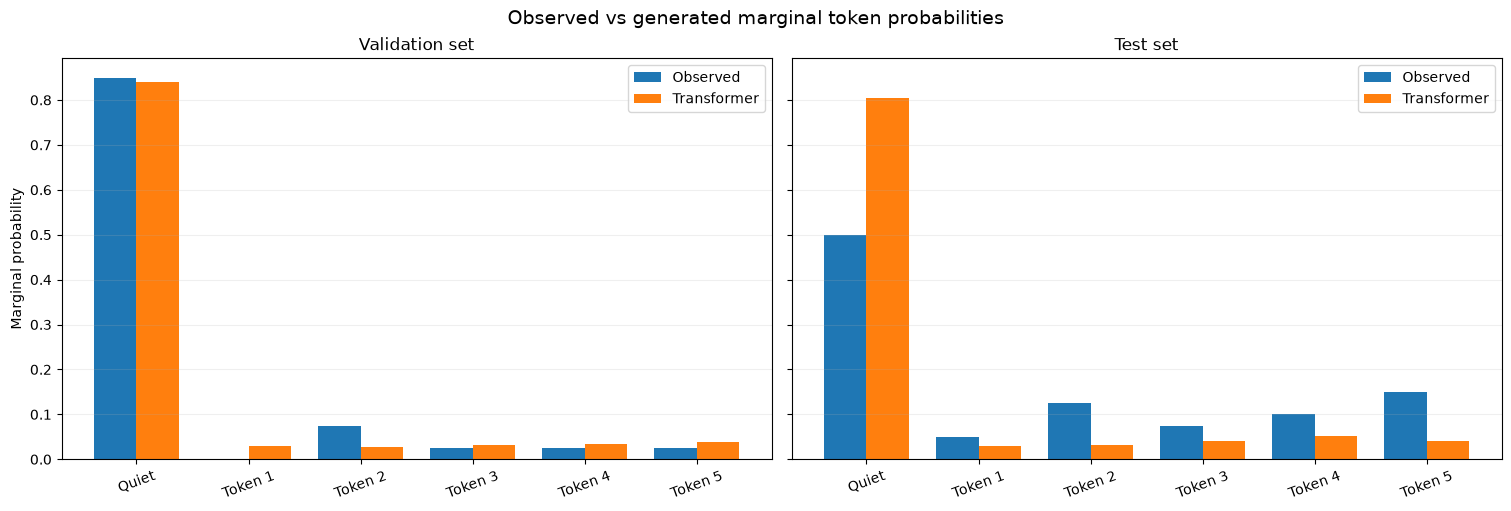

In [14]:
PREFIX_LENGTH = 10
N_FUTURE = 40
N_GENERATED = 1000

best_weights = torch.load(BEST_CHECKPOINT,map_location=device, weights_only=True)
model.load_state_dict(best_weights)
model.eval()


val_observed_prob, val_generated_prob, val_prefix, val_generated_future = marginal_probability_comparison(
    model=model,
    tokens=tokens_val,
    prefix_length=PREFIX_LENGTH,
    n_future=N_FUTURE,
    n_generated=N_GENERATED,
    context_len=CONTEXT_LEN,
    vocab_size=VOCAB_SIZE,
)


test_observed_prob, test_generated_prob, test_prefix, test_generated_future = marginal_probability_comparison(
    model=model,
    tokens=tokens_test,
    prefix_length=PREFIX_LENGTH,
    n_future=N_FUTURE,
    n_generated=N_GENERATED,
    context_len=CONTEXT_LEN,
    vocab_size=VOCAB_SIZE,
)


labels = ["Quiet", "Token 1", "Token 2", "Token 3", "Token 4", "Token 5"]
print("VALIDATION SET")
print("Token          Observed    Transformer")
for token in range(VOCAB_SIZE):
    print(
        f"{labels[token]:<14s}"
        f"{val_observed_prob[token]:>10.4f}"
        f"{val_generated_prob[token]:>15.4f}"
    )

print("\nTEST SET")
print("Token          Observed    Transformer")
for token in range(VOCAB_SIZE):
    print(
        f"{labels[token]:<14s}"
        f"{test_observed_prob[token]:>10.4f}"
        f"{test_generated_prob[token]:>15.4f}"
    )


x = np.arange(VOCAB_SIZE)
width = 0.38
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, constrained_layout=True)

axes[0].bar(x - width / 2, val_observed_prob, width, label="Observed")
axes[0].bar(x + width / 2, val_generated_prob, width, label="Transformer")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20)
axes[0].set_ylabel("Marginal probability")
axes[0].set_title("Validation set")
axes[0].grid(axis="y", alpha=0.2)
axes[0].legend()

axes[1].bar(x - width / 2, test_observed_prob, width, label="Observed")
axes[1].bar(x + width / 2, test_generated_prob, width, label="Transformer")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_title("Test set")
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend()
fig.suptitle("Observed vs generated marginal token probabilities", fontsize=14)
plt.show()

### What to take away

The continuous VAR-GARCH process is reduced to a categorical sequence $A_t$, and the Transformer learns a distribution for the next token from recent token history.

The diagnostics check complementary features:

- **NLL:** whether the model assigns useful predictive probability relative to an IID baseline;
- **transition matrix:** whether one-step token dependence is reproduced;
- **Monte Carlo rollout:** whether conditional token probabilities remain plausible when generation is repeated;
- **marginal probabilities:** whether generated sequences have similar overall token frequencies.

The model does not observe the latent volatility state, so some information is deliberately lost during tokenisation. The practical therefore illustrates both the usefulness and the limitations of modelling cascading extremes through categorical tokens.